In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel("cost_prediction.xlsx")

print(df.head())
print("Dataset shape:", df.shape)
print("Total number of rows:", len(df))
print("Total number of columns:", len(df.columns))
df.info()
df.isnull().sum()

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Dataset shape: (541909, 8)
Total number of rows: 541909
Total number of columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 column

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [3]:
# Remove rows where CustomerID is missing
df_clean = df.dropna(subset=["CustomerID"]).copy()

# Remove cancelled transactions
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only valid purchases
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Convert CustomerID to integer
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (541909, 8)
Cleaned shape: (397884, 8)


In [4]:
# Calculate total amount for each transaction
df_clean["TotalPrice"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

df_clean.head()

customer_data = df_clean.groupby("CustomerID").agg(
    TotalSpent=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    TotalTransactions=("InvoiceNo", "nunique"),
    AveragePrice=("UnitPrice", "mean")
).reset_index()

customer_data.head()

print("Customer data shape:", customer_data.shape)

customer_data.describe()

Customer data shape: (4338, 5)


,CustomerID,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2054.266460,1191.289073,4.272015,4.467773
std,1721.808492,8989.230441,5046.081546,7.697998,34.211451
min,12346.000000,3.750000,1.000000,1.000000,0.122500
25%,13813.250000,307.415000,160.000000,1.000000,2.203728
50%,15299.500000,674.485000,379.000000,2.000000,2.917611
75%,16778.750000,1661.740000,992.750000,5.000000,3.829784
max,18287.000000,280206.020000,196915.000000,209.000000,2033.100000


In [5]:
# Remove extreme outliers using the 99th percentile

features = ["TotalSpent", "TotalQuantity",
            "TotalTransactions", "AveragePrice"]

customer_filtered = customer_data.copy()

for column in features:
    upper_limit = customer_filtered[column].quantile(0.99)
    customer_filtered = customer_filtered[
        customer_filtered[column] <= upper_limit
    ]

print("Before removing outliers:", customer_data.shape)
print("After removing outliers:", customer_filtered.shape)




Before removing outliers: (4338, 5)
After removing outliers: (4167, 5)


In [6]:
X = customer_filtered[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[ 1.8967882   1.88858258  1.03201257 -0.35359895]
 [ 0.34375611  1.76124264  0.15545399  1.60543969]
 [ 0.31922538 -0.09987955 -0.72110459  3.18995843]
 [-0.56036424 -0.57223454 -0.72110459  0.39789829]
 [-0.71203574 -0.76487701 -0.72110459  1.80013738]]


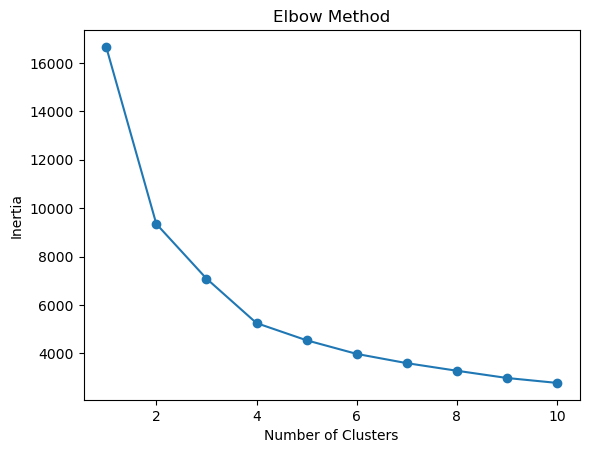

In [7]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [8]:
#Train the final K-Means model
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_filtered["Cluster"] = kmeans.fit_predict(X_scaled)

customer_filtered.head()

,CustomerID,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice,Cluster
1,12347,4310.00,2458,7,2.644011,1
2,12348,1797.24,2341,4,5.764839,1
3,12349,1757.55,631,1,8.289041,3
4,12350,334.40,197,1,3.841176,0
6,12353,89.00,20,1,6.075000,3


In [10]:
#See how many customers are in each cluster
print(customer_filtered["Cluster"].value_counts().sort_index())

Cluster
0    2509
1     828
2     211
3     619
Name: count, dtype: int64


In [11]:
cluster_summary = customer_filtered.groupby("Cluster")[features].mean()

cluster_summary

,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice
Cluster,,,,
0,555.150754,355.911917,1.994022,2.627630
1,2474.300364,1473.334541,6.541063,2.944263
2,6364.261659,3604.009479,12.943128,3.013414
3,625.224170,223.634895,2.101777,5.974879


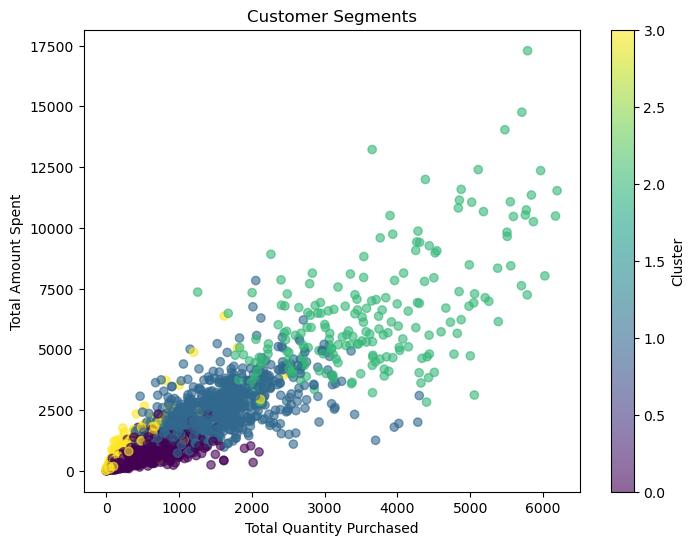

In [12]:
#Visualize the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    customer_filtered["TotalQuantity"],
    customer_filtered["TotalSpent"],
    c=customer_filtered["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Total Quantity Purchased")
plt.ylabel("Total Amount Spent")
plt.title("Customer Segments")
plt.colorbar(label="Cluster")

plt.show()

In [13]:
# Enter details of a new customer

total_spent = float(input("Enter Total Amount Spent: "))
total_quantity = float(input("Enter Total Quantity Purchased: "))
total_transactions = float(input("Enter Total Number of Transactions: "))
average_price = float(input("Enter Average Product Price: "))

new_customer = pd.DataFrame([{
    "TotalSpent": total_spent,
    "TotalQuantity": total_quantity,
    "TotalTransactions": total_transactions,
    "AveragePrice": average_price
}])

# Scale using the same scaler used during training
new_customer_scaled = scaler.transform(new_customer)

# Predict cluster
predicted_cluster = kmeans.predict(new_customer_scaled)[0]

print("\nPredicted Customer Cluster:", predicted_cluster)

Enter Total Amount Spent:  1000
Enter Total Quantity Purchased:  500
Enter Total Number of Transactions:  3
Enter Average Product Price:  3



Predicted Customer Cluster: 0


In [14]:
cluster_summary = customer_filtered.groupby("Cluster")[[
    "TotalSpent",
    "TotalQuantity",
    "TotalTransactions",
    "AveragePrice"
]].mean().round(2)

cluster_summary

,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice
Cluster,,,,
0,555.15,355.91,1.99,2.63
1,2474.30,1473.33,6.54,2.94
2,6364.26,3604.01,12.94,3.01
3,625.22,223.63,2.10,5.97


In [15]:
#Make the prediction meaningful
cluster_summary = customer_filtered.groupby("Cluster")[[
    "TotalSpent",
    "TotalQuantity",
    "TotalTransactions",
    "AveragePrice"
]].mean().round(2)

cluster_summary

,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice
Cluster,,,,
0,555.15,355.91,1.99,2.63
1,2474.30,1473.33,6.54,2.94
2,6364.26,3604.01,12.94,3.01
3,625.22,223.63,2.10,5.97


In [16]:
#Cluster Summary
cluster_summary = customer_filtered.groupby("Cluster")[[
    "TotalSpent",
    "TotalQuantity",
    "TotalTransactions",
    "AveragePrice"
]].mean().round(2)

cluster_summary

,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice
Cluster,,,,
0,555.15,355.91,1.99,2.63
1,2474.30,1473.33,6.54,2.94
2,6364.26,3604.01,12.94,3.01
3,625.22,223.63,2.10,5.97


In [17]:
#Automatically name the clusters
# Rank clusters according to average spending
spending_order = cluster_summary["TotalSpent"].sort_values().index.tolist()

cluster_names = {
    spending_order[0]: "Low Value Customer",
    spending_order[1]: "Regular Customer",
    spending_order[2]: "High Value Customer",
    spending_order[3]: "Premium Customer"
}

customer_filtered["CustomerType"] = customer_filtered["Cluster"].map(cluster_names)

customer_filtered[[
    "CustomerID",
    "TotalSpent",
    "TotalQuantity",
    "TotalTransactions",
    "AveragePrice",
    "Cluster",
    "CustomerType"
]].head(10)

,CustomerID,TotalSpent,TotalQuantity,TotalTransactions,AveragePrice,Cluster,CustomerType
1,12347,4310.00,2458,7,2.644011,1,High Value Customer
2,12348,1797.24,2341,4,5.764839,1,High Value Customer
3,12349,1757.55,631,1,8.289041,3,Regular Customer
4,12350,334.40,197,1,3.841176,0,Low Value Customer
6,12353,89.00,20,1,6.075000,3,Regular Customer
7,12354,1079.40,530,1,4.503793,3,Regular Customer
8,12355,459.40,240,1,4.203846,0,Low Value Customer
9,12356,2811.43,1591,3,3.201186,1,High Value Customer
10,12357,6207.67,2708,1,3.348626,1,High Value Customer
11,12358,1168.06,248,2,8.274211,3,Regular Customer


In [18]:
#Final Prediction
total_spent = float(input("Enter Total Amount Spent: "))
total_quantity = float(input("Enter Total Quantity Purchased: "))
total_transactions = float(input("Enter Total Number of Transactions: "))
average_price = float(input("Enter Average Product Price: "))

new_customer = pd.DataFrame([{
    "TotalSpent": total_spent,
    "TotalQuantity": total_quantity,
    "TotalTransactions": total_transactions,
    "AveragePrice": average_price
}])

new_customer_scaled = scaler.transform(new_customer)

predicted_cluster = kmeans.predict(new_customer_scaled)[0]

predicted_type = cluster_names[predicted_cluster]

print("\n--- Prediction Result ---")
print("Predicted Cluster:", predicted_cluster)
print("Predicted Customer Type:", predicted_type)

Enter Total Amount Spent:  1000
Enter Total Quantity Purchased:  500
Enter Total Number of Transactions:  3
Enter Average Product Price:  3



--- Prediction Result ---
Predicted Cluster: 0
Predicted Customer Type: Low Value Customer


In [19]:
customer_filtered.to_csv("customer_segmentation_results.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
